[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/edavishahl/ENGR240/blob/main/Class%20Demos%20and%20Activities/Week%201/Contaminant_Decay_Sensitivity_Analysis.ipynb)

# Introduction to Parameter Sensitivity Analysis
## Contaminant Decay Model Example

This notebook introduces fundamental concepts in scientific computing by exploring how changes in model parameters affect system behavior - a technique known as **parameter sensitivity analysis**.

### Learning Objectives
- Understand how to implement a simple mathematical model in Python
- Learn how to conduct a basic parameter sensitivity analysis
- Visualize and interpret model sensitivity to parameter changes
- Apply scientific computing techniques to analyze environmental remediation scenarios

### The Contaminant Decay Model

We'll explore a two-component contaminant decay model described by the equation:

$$p(t) = A_0 \cdot e^{-k_A \cdot t} + B_0 \cdot e^{-k_B \cdot t}$$

Where:
- $p(t)$ = total contaminant concentration (ppm) at time $t$
- $t$ = time (days)
- $A_0$ = initial concentration of contaminant A (ppm)
- $B_0$ = initial concentration of contaminant B (ppm)
- $k_A$ = decay rate of contaminant A (day$^{-1}$)
- $k_B$ = decay rate of contaminant B (day$^{-1}$)

This model represents two contaminants that decay independently according to first-order kinetics (exponential decay), which is common in environmental engineering applications.

## Setup

First, we'll import the necessary Python libraries for numerical computing and visualization.

In [1]:
import numpy as np  # For numerical operations
import matplotlib.pyplot as plt  # For creating plots

# Set plot style for better visualization
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = [10, 6]  # Set default figure size

## Model Parameters

Let's define our model parameters. In this example, we'll:
1. Keep the initial concentrations ($A_0$ and $B_0$) constant
2. Keep the decay rate of contaminant A ($k_A$) constant
3. Vary the decay rate of contaminant B ($k_B$) to analyze its effect on the total concentration

A higher decay rate means the contaminant breaks down more quickly. The units day$^{-1}$ represent the fraction of the contaminant that decays per day.

In [2]:
# Model parameters
A0 = 200  # Initial concentration of contaminant A (ppm)
B0 = 100  # Initial concentration of contaminant B (ppm)
kA = 1    # Decay rate of contaminant A (day^-1)

# The parameter values we're using in our sensitivity analysis
kB1 = 0.5  # First decay rate for contaminant B (day^-1)
kB2 = 1.0  # Second decay rate for contaminant B (day^-1)
kB3 = 2.0  # Third decay rate for contaminant B (day^-1)
kB4 = 5.0  # Fourth decay rate for contaminant B (day^-1)

# Time domain for simulation
t = np.linspace(0, 6, 100)  # 100 time points from 0 to 6 days

# Define a regulatory standard concentration (for reference)
standard = 10  # ppm

## The Exponential Decay Function

Exponential decay is described by the function $f(t) = f_0 \cdot e^{-kt}$, where:
- $f_0$ is the initial value (at $t=0$)
- $k$ is the decay rate constant
- $t$ is time

Important properties of exponential decay:
- At $t=0$, the function equals $f_0$
- As $t$ increases, the function approaches zero
- The half-life (time for the quantity to reduce by half) is $t_{1/2} = \ln(2)/k$

In our contaminant model, we're summing two exponential decay terms, each with its own initial value and decay rate.

## Calculate Contaminant Concentrations

Now we'll calculate the total contaminant concentration over time for each value of $k_B$.

In [3]:
# Calculate concentrations for each kB value individually

# First scenario - kB = 0.5
p1 = A0 * np.exp(-kA * t) + B0 * np.exp(-kB1 * t)

# Second scenario - kB = 1.0
p2 = A0 * np.exp(-kA * t) + B0 * np.exp(-kB2 * t)

# Third scenario - kB = 2.0
p3 = A0 * np.exp(-kA * t) + B0 * np.exp(-kB3 * t)

# Fourth scenario - kB = 5.0
p4 = A0 * np.exp(-kA * t) + B0 * np.exp(-kB4 * t)

# Print the half-life for each scenario
half_life_A = np.log(2) / kA

half_life_B1 = np.log(2) / kB1
print(f"When kB = {kB1}:")
print(f"  Half-life of contaminant A: {half_life_A:.2f} days")
print(f"  Half-life of contaminant B: {half_life_B1:.2f} days\n")

half_life_B2 = np.log(2) / kB2
print(f"When kB = {kB2}:")
print(f"  Half-life of contaminant A: {half_life_A:.2f} days")
print(f"  Half-life of contaminant B: {half_life_B2:.2f} days\n")

half_life_B3 = np.log(2) / kB3
print(f"When kB = {kB3}:")
print(f"  Half-life of contaminant A: {half_life_A:.2f} days")
print(f"  Half-life of contaminant B: {half_life_B3:.2f} days\n")

half_life_B4 = np.log(2) / kB4
print(f"When kB = {kB4}:")
print(f"  Half-life of contaminant A: {half_life_A:.2f} days")
print(f"  Half-life of contaminant B: {half_life_B4:.2f} days\n")

When kB = 0.5:
  Half-life of contaminant A: 0.69 days
  Half-life of contaminant B: 1.39 days

When kB = 1.0:
  Half-life of contaminant A: 0.69 days
  Half-life of contaminant B: 0.69 days

When kB = 2.0:
  Half-life of contaminant A: 0.69 days
  Half-life of contaminant B: 0.35 days

When kB = 5.0:
  Half-life of contaminant A: 0.69 days
  Half-life of contaminant B: 0.14 days



## Visualize the Results

Let's create a plot to visualize how changing the decay rate of contaminant B affects the total concentration over time.

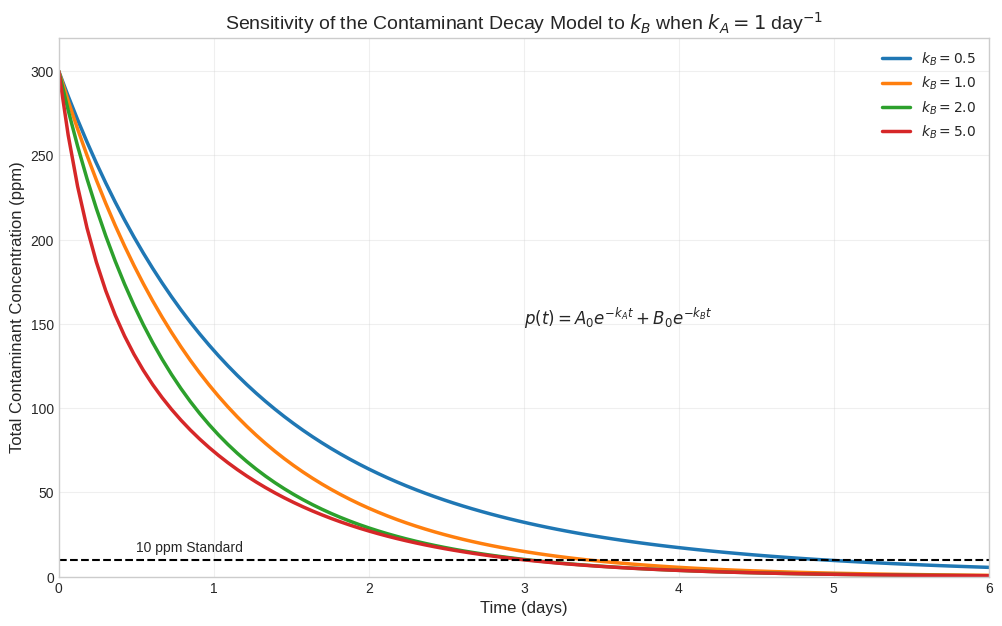

In [7]:
# Create the plot
plt.figure(figsize=(12, 7))

# Plot each scenario individually
plt.plot(t, p1, linewidth=2.5, label=f'$k_B = {kB1}$')
plt.plot(t, p2, linewidth=2.5, label=f'$k_B = {kB2}$')
plt.plot(t, p3, linewidth=2.5, label=f'$k_B = {kB3}$')
plt.plot(t, p4, linewidth=2.5, label=f'$k_B = {kB4}$')

# Add the regulatory standard as a horizontal line
plt.plot(t, standard * np.ones_like(t), 'k--', linewidth=1.5)
plt.text(0.5, standard + 5, f'{standard} ppm Standard', fontsize=10)

# Add the model equation to the plot
plt.text(3, 150, '$p(t) = A_0 e^{-k_A t} + B_0 e^{-k_B t}$', fontsize=12)

# Add labels and legend
plt.title('Sensitivity of the Contaminant Decay Model to $k_B$ when $k_A = 1$ day$^{-1}$', fontsize=14)
plt.xlabel('Time (days)', fontsize=12)
plt.ylabel('Total Contaminant Concentration (ppm)', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

# Set axis limits for better visualization
plt.ylim(0, 320)
plt.xlim(0, 6)

plt.show()

## Interpreting the Results

From the plot above, we can observe several key insights:

1. **Initial concentration**: At time t=0, all curves start at the same point (300 ppm), which is the sum of $A_0$ (200 ppm) and $B_0$ (100 ppm).

2. **Decay rate impact**: As $k_B$ increases, the overall concentration decreases more rapidly. This makes intuitive sense - a higher decay rate means faster breakdown of the contaminant.

3. **Compliance timeline**: The dashed line represents a regulatory standard of 10 ppm. We can see that different values of $k_B$ result in different times to reach this standard:
   - With $k_B = 0.5$ (slowest decay), it takes longest to reach the standard
   - With $k_B = 5$ (fastest decay), it takes the least time

4. **Long-term behavior**: As time increases, the curves begin to converge. This occurs because contaminant B eventually decays to negligible levels regardless of $k_B$, and the long-term behavior becomes dominated by contaminant A (which has a constant decay rate in all scenarios).

This sensitivity analysis helps engineers and scientists understand how important the decay rate of contaminant B is to the overall remediation timeline, which could inform decisions about treatment methods.

## Application and Discussion

### Real-world Significance

This type of model is commonly used in environmental engineering to predict how long it will take for contaminated sites to reach acceptable concentration levels. Some examples include:

- **Groundwater remediation**: Predicting how long natural attenuation will take to clean up a contaminated aquifer
- **Soil contamination**: Estimating the timeline for bioremediation of petroleum hydrocarbons
- **Radioactive decay**: Calculating safe storage periods for radioactive waste (though radioactive decay often involves more complex chains)

### Scientific Computing Concepts Demonstrated

This simple example demonstrates several key scientific computing concepts:

- **Numerical model implementation**: Translating mathematical equations into computational code
- **Parameter sensitivity analysis**: Systematically varying model parameters to understand their impact
- **Data visualization**: Effectively communicating results through appropriate plotting
- **Model interpretation**: Drawing meaningful conclusions from computational results